`Vocabulary Diversity Indices`

Type-Token Ratio is used to estimate the lexical diversity of a text.
TTR = Number of unique words/ total number of words
- A higher TTR means greater lexical diversity.
- A lower TTR means more repetition of words.

ype-Token Ratio (TTR) is known to be biased by text length (as the length increases, TTR tends to decrease due to repeated words, even if the vocabulary is diverse).

To address this, we we use MATTR (Moving-Average Type-Token Ratio). Instead of calculating TTR over the entire text, MATTR measures lexical diversity in local segments. It works by sliding a fixed-size window (e.g., 100 words) across the text, one word at a time. At each step, it calculates the TTR for that window. The final score is the average of all those micro TTRs.


In [3]:
import math
import regex as re
import unicodedata
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
def preprocess(text):
    if not isinstance(text, str):
        return ""
    text = unicodedata.normalize('NFC', text)
    text = text.lower()
    text = re.sub(r"[^\p{L}\s'-]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize_text(text):
    if isinstance(text, pd.Series) or isinstance(text, list):
        tokens = []
        for row in text:
            row = preprocess(row)
            tokens.extend(re.findall(r"\p{L}+(?:['-]\p{L}+)*", row))
        return tokens
    elif isinstance(text, str):
        text = preprocess(text)
        return re.findall(r"\p{L}+(?:['-]\p{L}+)*", text)
    else:
        return []

In [5]:
def calculate_ttr(text):
    tokens = tokenize_text(text)
    if not tokens:
        return 0.0
    unique_tokens = set(tokens)
    return len(unique_tokens) / len(tokens) 

In [ ]:
def calculate_mattr(text, window_size=500):
    tokens = tokenize_text(text)
    if not tokens:
        return 0.0

    if len(tokens) < window_size:
        return calculate_ttr(tokens)

    def sliding_window(tokens, win_size):
        return [tokens[i:i + win_size] for i in range(len(tokens) - win_size + 1)]

    windows = sliding_window(tokens, window_size)
    scores = [len(set(window)) / window_size for window in windows]

    return sum(scores) / len(scores)
 

In [ ]:
rf_text = pd.read_csv("C:/Users/DELL/Desktop/translation_evaluator/data/YANKARI.csv")["text"][:30]

In [51]:
scores = wura_text.apply(calculate_mattr)

for index, score in enumerate(scores):
    print(f"Document {index + 1}: {score:.4f}")

Document 1: 0.5854
Document 2: 0.5639
Document 3: 0.6633
Document 4: 0.6562
Document 5: 0.3909
Document 6: 0.3653
Document 7: 0.3845
Document 8: 0.4083
Document 9: 0.3963
Document 10: 0.3489
Document 11: 0.4895
Document 12: 0.5350
Document 13: 0.6855
Document 14: 0.6606
Document 15: 0.7553
Document 16: 0.7195
Document 17: 0.5825
Document 18: 0.5847
Document 19: 0.4458
Document 20: 0.5417
Document 21: 0.6728
Document 22: 0.6074
Document 23: 0.5743
Document 24: 0.5569
Document 25: 0.4764
Document 26: 0.6705
Document 27: 0.5793
Document 28: 0.7143
Document 29: 0.5897
Document 30: 0.5921
Document 31: 0.5526
Document 32: 0.4394
Document 33: 0.5617
Document 34: 0.5040
Document 35: 0.6887
Document 36: 0.5500
Document 37: 0.6224
Document 38: 0.4429
Document 39: 0.6549
Document 40: 0.6947
Document 41: 0.5654
Document 42: 0.5169
Document 43: 0.5703
Document 44: 0.6582
Document 45: 0.4934
Document 46: 0.6560
Document 47: 0.6744
Document 48: 0.6124
Document 49: 0.5532
Document 50: 0.7582
Document 

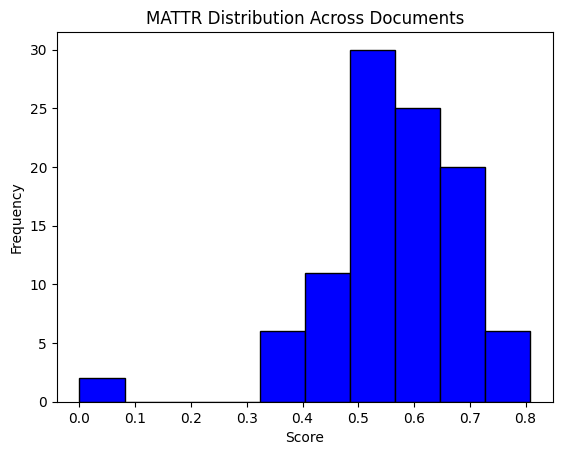

In [55]:
plt.hist(scores, color='blue', edgecolor='black')
plt.title('MATTR Distribution Across Documents')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

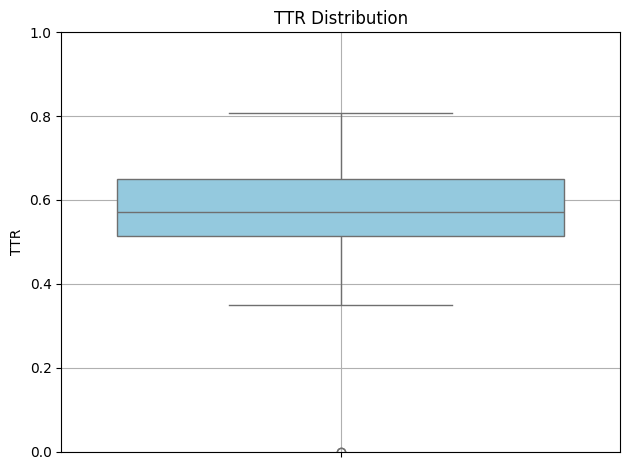

In [56]:
import seaborn as sns

sns.boxplot(data=scores, color='skyblue')
plt.title('TTR Distribution')
plt.ylabel('TTR')
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.show()